# DS8005: MRP 2026 :Exploratory Data Analysis Notebook

**Project Title:** MMachine Learning Based Remaining Useful Life (RUL) Prediction of Rotating Equipment Using NASA C-MAPSS Data
**Student:** Aman Kaushik  
**Student ID:** 501214203  
**Dataset:** NASA C-MAPSS FD001 Turbofan Engine Degradation Dataset  

## 1. Dataset Download 

Download the NASA C-MAPSS dataset and place these files in the same folder as this notebook:

- `train_FD001.txt`
- `test_FD001.txt`
- `RUL_FD001.txt`

Dataset link: https://data.nasa.gov/dataset/cmapss-jet-engine-simulated-data


In [1]:
# Import required libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (10, 6)


## 2. Load NASA C-MAPSS FD001 Dataset

In [25]:
# column names according to NASA C-MAPSS dataset structure

index_cols = ["engine_id", "cycle"]
setting_cols = ["setting_1", "setting_2", "setting_3"]
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]
columns = index_cols + setting_cols + sensor_cols

DATA_DIR = "."

train_path = os.path.join(DATA_DIR, "train_FD001.txt")
test_path = os.path.join(DATA_DIR, "test_FD001.txt")
rul_path = os.path.join(DATA_DIR, "RUL_FD001.txt")

train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=columns)
test_df = pd.read_csv(test_path, sep=r"\s+", header=None, names=columns)
rul_df = pd.read_csv(rul_path, sep=r"\s+", header=None, names=["true_RUL"])

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)
print("RUL data shape:", rul_df.shape)

train_df.head()


Training data shape: (20631, 26)
Testing data shape: (13096, 26)
RUL data shape: (100, 1)


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 3. Create Remaining Useful Life (RUL) Target

For the training dataset, each engine is monitored until failure. Therefore, RUL can be calculated as:

**RUL = maximum cycle for that engine − current cycle**


In [26]:
# Calculate RUL for training data

max_cycles = train_df.groupby("engine_id")["cycle"].max().reset_index()
max_cycles.columns = ["engine_id", "max_cycle"]

train_df = train_df.merge(max_cycles, on="engine_id", how="left")
train_df["RUL"] = train_df["max_cycle"] - train_df["cycle"]
train_df = train_df.drop(columns=["max_cycle"])

train_df[["engine_id", "cycle", "RUL"]].head(10)


,engine_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


## 4. Dataset Summary

In [27]:
print("Number of training engines:", train_df["engine_id"].nunique())
print("Number of testing engines:", test_df["engine_id"].nunique())
print("Number of sensor variables:", len(sensor_cols))
print("Number of operating settings:", len(setting_cols))
print("Training observations:", len(train_df))
print("Testing observations:", len(test_df))


Number of training engines: 100
Number of testing engines: 100
Number of sensor variables: 21
Number of operating settings: 3
Training observations: 20631
Testing observations: 13096


In [28]:
# Descriptive statistics

train_df.describe().T


,count,mean,std,min,25%,50%,75%,max
engine_id,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200


## 5. Missing Value Assessment

In [29]:
missing_values = train_df.isnull().sum()
missing_values[missing_values > 0]


Series([], dtype: int64)

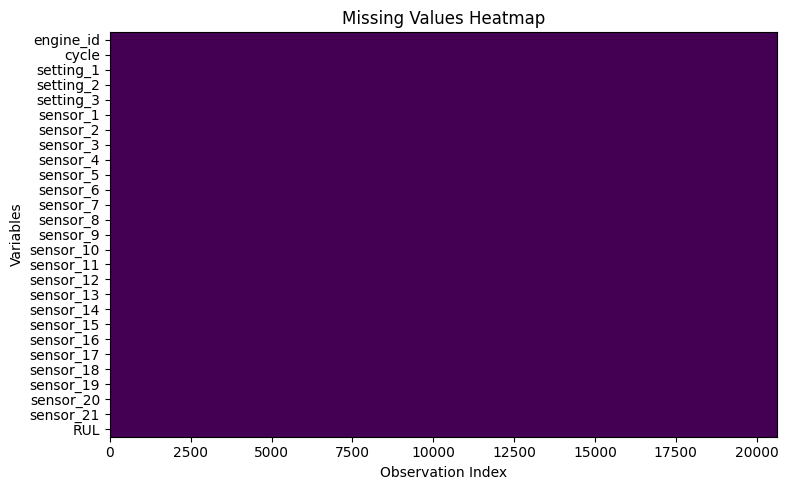

In [30]:
# Missing values heatmap using matplotlib

missing_matrix = train_df.isnull().astype(int)

plt.figure(figsize=(8, 5))
plt.imshow(missing_matrix.T, aspect="auto", interpolation="nearest")
plt.title("Missing Values Heatmap")
plt.xlabel("Observation Index")
plt.ylabel("Variables")
plt.yticks(range(len(train_df.columns)), train_df.columns)
plt.tight_layout()
plt.show()


## 6. Engine Lifetime Distribution:
This plot shows how many operating cycles each engine completed before failure. This is important because the dataset contains multiple individual degradation histories.


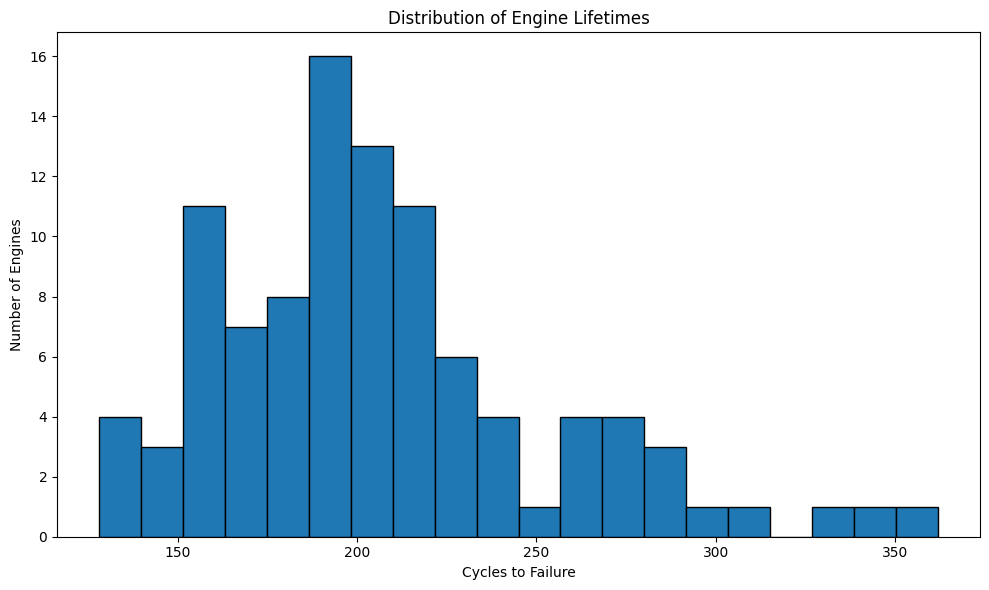

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

In [31]:
engine_life = train_df.groupby("engine_id")["cycle"].max()

plt.figure()
plt.hist(engine_life, bins=20, edgecolor="black")
plt.title("Distribution of Engine Lifetimes")
plt.xlabel("Cycles to Failure")
plt.ylabel("Number of Engines")
plt.tight_layout()
plt.show()

engine_life.describe()


## 7. Remaining Useful Life Distribution

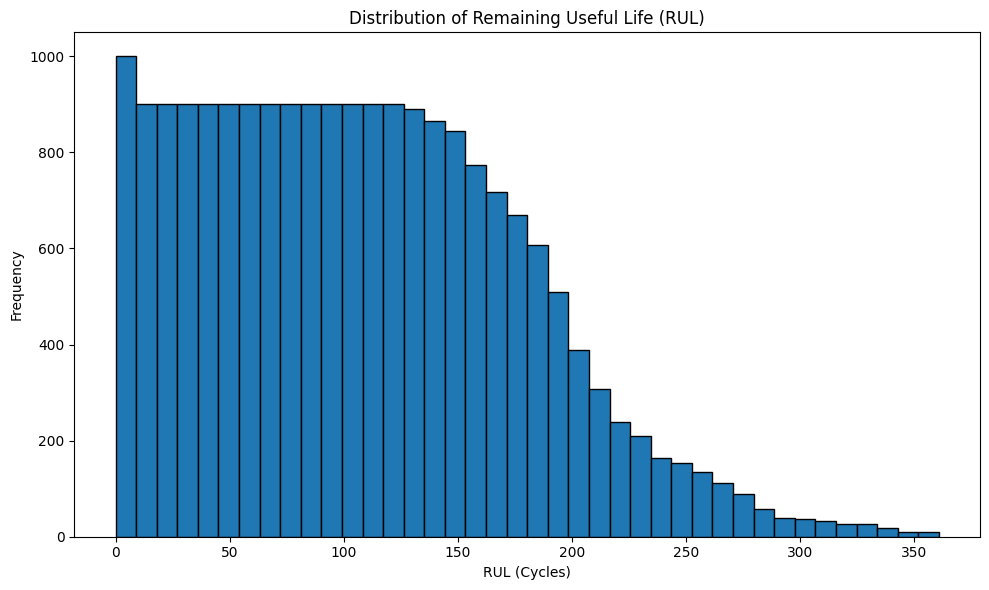

count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64

In [11]:
plt.figure()
plt.hist(train_df["RUL"], bins=40, edgecolor="black")
plt.title("Distribution of Remaining Useful Life (RUL)")
plt.xlabel("RUL (Cycles)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

train_df["RUL"].describe()


## 8. Sensor Variability & Feature Screening

Some sensors in FD001 may be nearly constant and may not contribute strongly to prediction.


In [32]:
sensor_variance = train_df[sensor_cols].var().sort_values()

sensor_variance_df = sensor_variance.reset_index()
sensor_variance_df.columns = ["Sensor", "Variance"]
sensor_variance_df


,Sensor,Variance
0,sensor_1,0.000000e+00
1,sensor_10,0.000000e+00
2,sensor_19,0.000000e+00
3,sensor_18,0.000000e+00
4,sensor_16,1.203765e-35
5,sensor_5,2.840037e-29
6,sensor_6,1.929279e-06
7,sensor_15,1.406628e-03
8,sensor_8,5.038938e-03
9,sensor_13,5.172330e-03


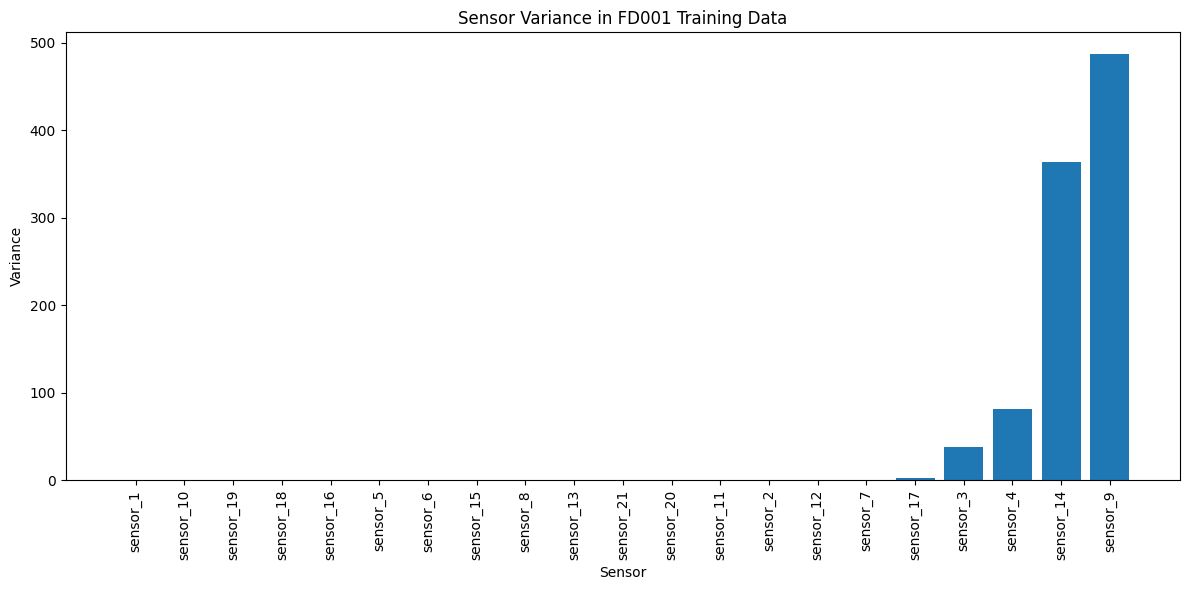

In [33]:
plt.figure(figsize=(12, 6))
plt.bar(sensor_variance.index, sensor_variance.values)
plt.title("Sensor Variance in FD001 Training Data")
plt.xlabel("Sensor")
plt.ylabel("Variance")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## 9. Correlation Between Sensors and RUL

This helps identify which sensors have stronger linear relationships with degradation and RUL.


In [34]:
rul_corr = train_df[sensor_cols + ["RUL"]].corr()["RUL"].drop("RUL").sort_values()

rul_corr_df = rul_corr.reset_index()
rul_corr_df.columns = ["Sensor", "Correlation_with_RUL"]
rul_corr_df


,Sensor,Correlation_with_RUL
0,sensor_11,-0.696228
1,sensor_4,-0.678948
2,sensor_15,-0.642667
3,sensor_2,-0.606484
4,sensor_17,-0.606154
5,sensor_3,-0.584520
6,sensor_8,-0.563968
7,sensor_13,-0.562569
8,sensor_9,-0.390102
9,sensor_14,-0.306769


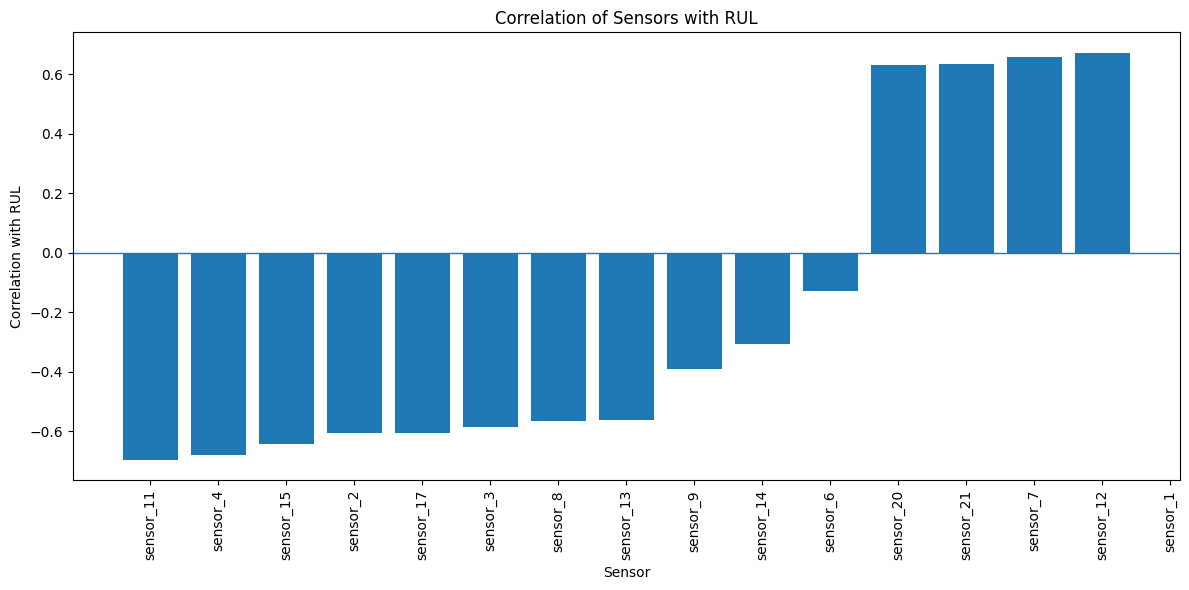

In [35]:
plt.figure(figsize=(12, 6))
plt.bar(rul_corr.index, rul_corr.values)
plt.title("Correlation of Sensors with RUL")
plt.xlabel("Sensor")
plt.ylabel("Correlation with RUL")
plt.xticks(rotation=90)
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()


## 10. Sensor Correlation Matrix

Highly correlated sensors may contain redundant information.


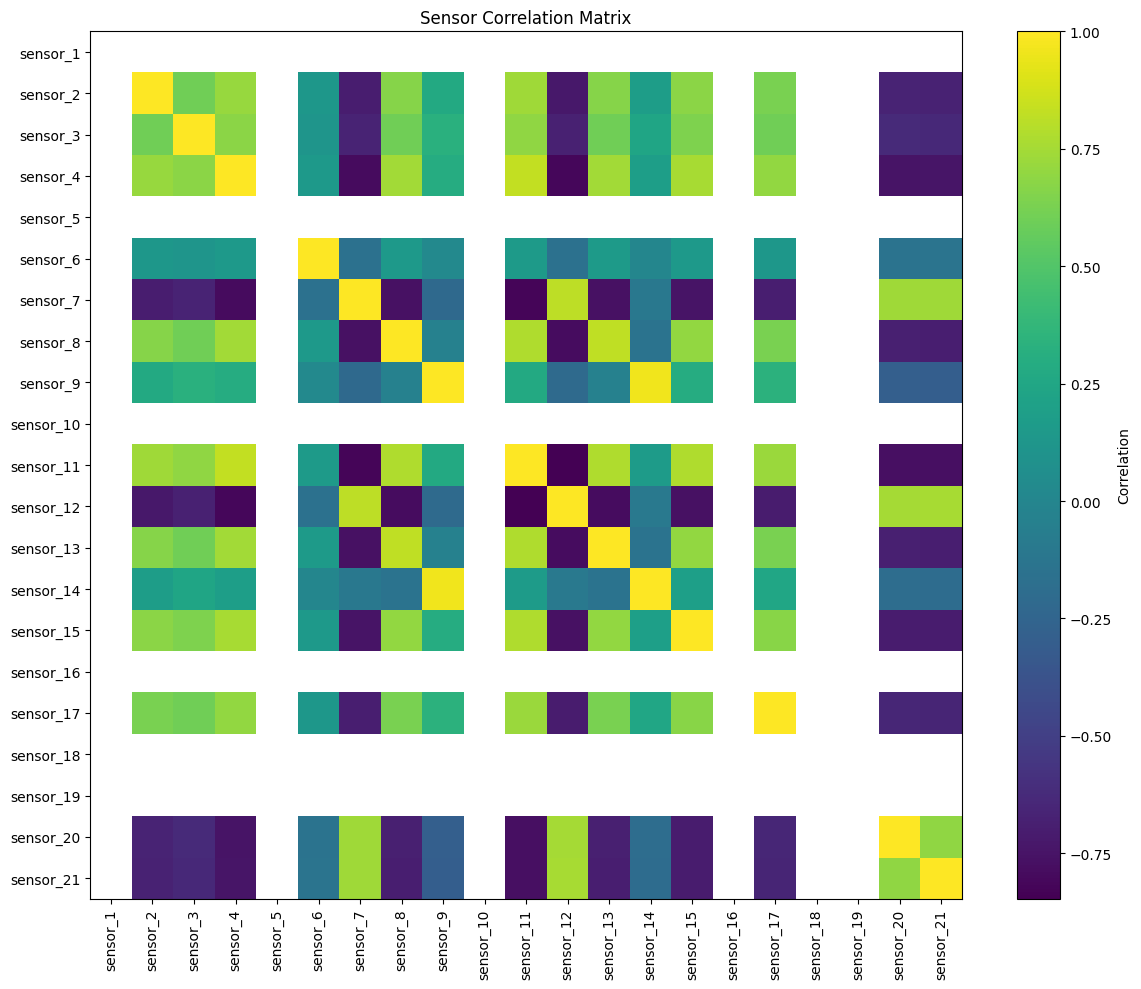

In [36]:
corr_matrix = train_df[sensor_cols].corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.title("Sensor Correlation Matrix")
plt.xticks(range(len(sensor_cols)), sensor_cols, rotation=90)
plt.yticks(range(len(sensor_cols)), sensor_cols)
plt.tight_layout()
plt.show()


## 11. Degradation Trends for Selected Engines

These plots show sensor behaviour over operating cycles for individual engines.


In [37]:
# Select sensors with stronger relationship to RUL
selected_sensors = list(rul_corr.abs().sort_values(ascending=False).head(4).index)
selected_sensors


['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7']

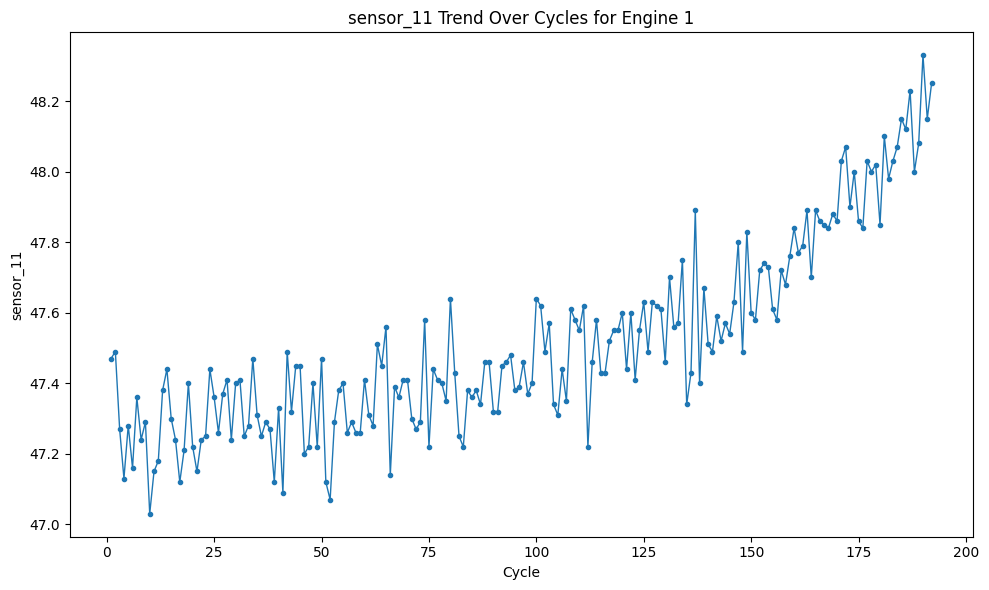

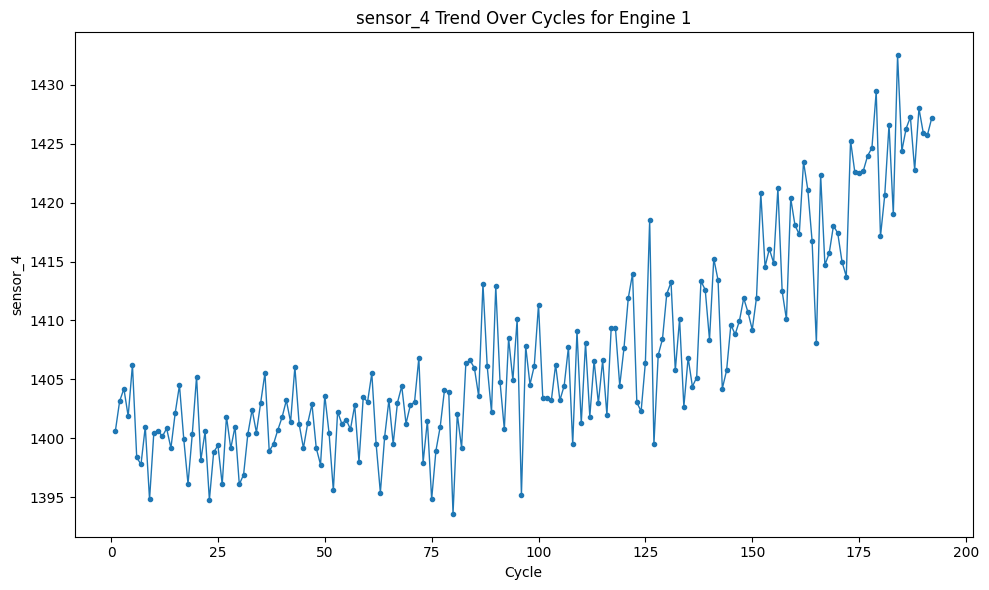

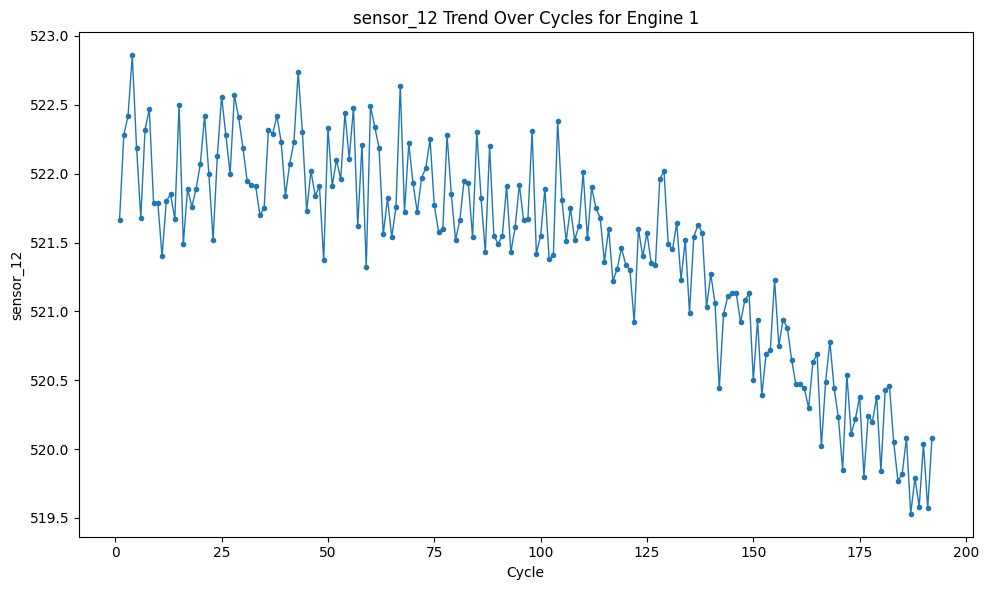

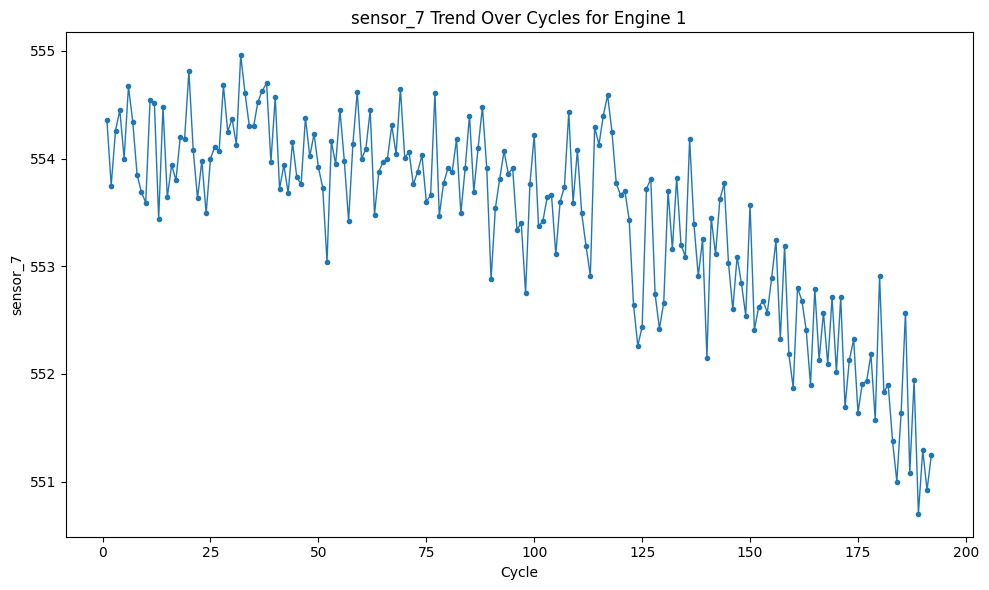

In [38]:
# Plot selected sensor trends for Engine 1

engine_id = 1
engine_data = train_df[train_df["engine_id"] == engine_id]

for sensor in selected_sensors:
    plt.figure()
    plt.plot(engine_data["cycle"], engine_data[sensor], marker=".", linewidth=1)
    plt.title(f"{sensor} Trend Over Cycles for Engine {engine_id}")
    plt.xlabel("Cycle")
    plt.ylabel(sensor)
    plt.tight_layout()
    plt.show()


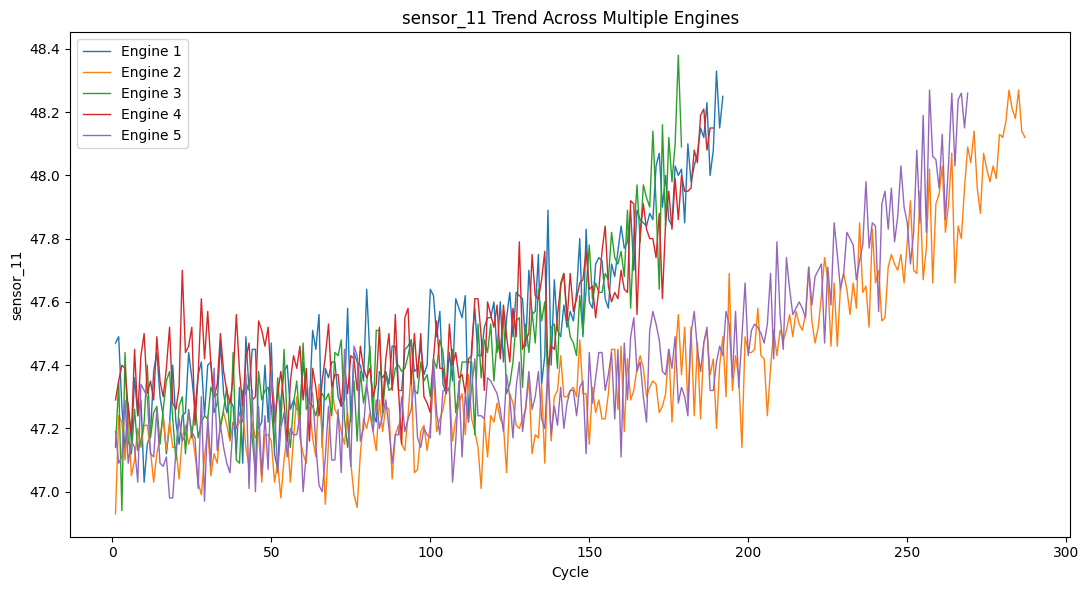

In [39]:
# Compare the same sensor across several engines

sensor_to_plot = selected_sensors[0]
sample_engines = [1, 2, 3, 4, 5]

plt.figure(figsize=(11, 6))
for eid in sample_engines:
    temp = train_df[train_df["engine_id"] == eid]
    plt.plot(temp["cycle"], temp[sensor_to_plot], linewidth=1, label=f"Engine {eid}")

plt.title(f"{sensor_to_plot} Trend Across Multiple Engines")
plt.xlabel("Cycle")
plt.ylabel(sensor_to_plot)
plt.legend()
plt.tight_layout()
plt.show()


## 12. RUL Degradation Curves

This confirms that each engine has a unique run-to-failure degradation history.


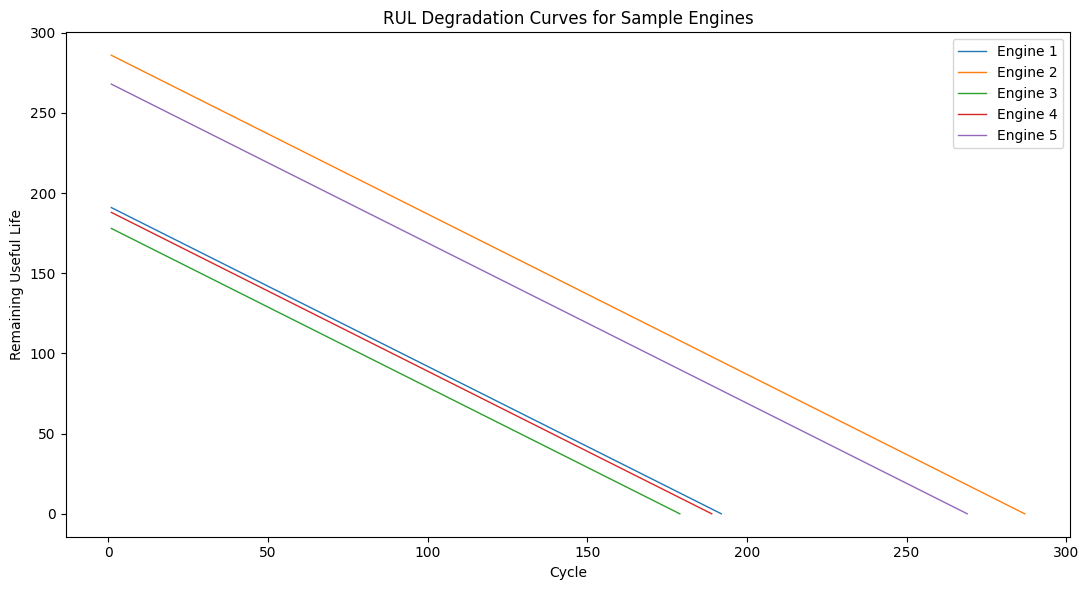

In [20]:
plt.figure(figsize=(11, 6))

for eid in sample_engines:
    temp = train_df[train_df["engine_id"] == eid]
    plt.plot(temp["cycle"], temp["RUL"], linewidth=1, label=f"Engine {eid}")

plt.title("RUL Degradation Curves for Sample Engines")
plt.xlabel("Cycle")
plt.ylabel("Remaining Useful Life")
plt.legend()
plt.tight_layout()
plt.show()


## 13. Boxplots for Selected Sensors

Boxplots help identify spread and possible outliers in important sensor variables.


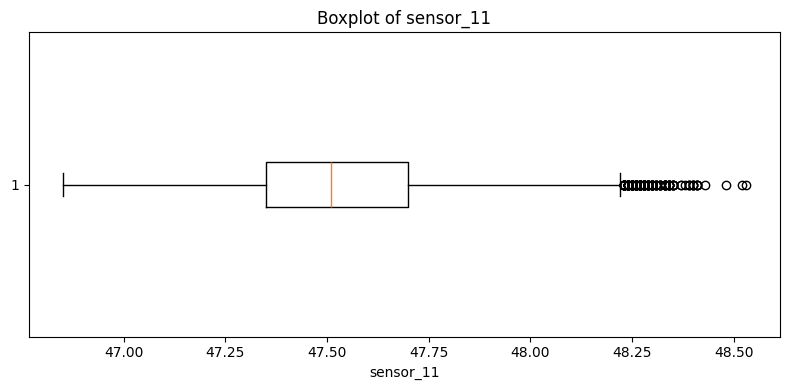

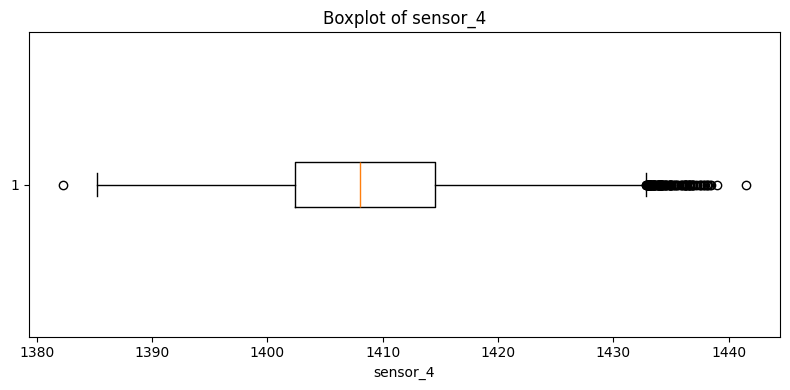

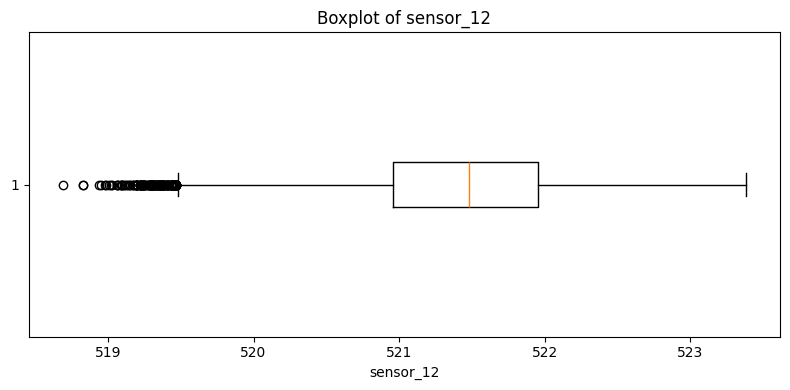

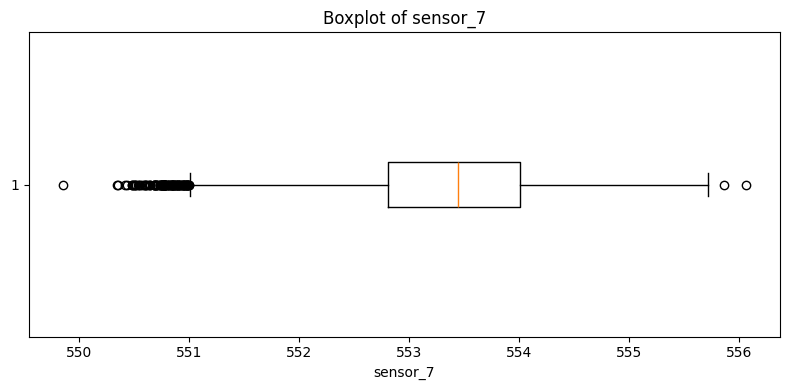

In [21]:
for sensor in selected_sensors:
    plt.figure(figsize=(8, 4))
    plt.boxplot(train_df[sensor].dropna(), vert=False)
    plt.title(f"Boxplot of {sensor}")
    plt.xlabel(sensor)
    plt.tight_layout()
    plt.show()


## 14. PCA Visualization of Sensor Data

PCA is used only for visualization. It helps show whether sensor measurements contain patterns related to equipment degradation.


In [22]:
# Remove near-constant sensors before PCA
useful_sensors = sensor_variance[sensor_variance > 1e-6].index.tolist()

X = train_df[useful_sensors]
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": pca_result[:, 0],
    "PC2": pca_result[:, 1],
    "RUL": train_df["RUL"]
})

print("Explained variance ratio:", pca.explained_variance_ratio_)
pca_df.head()


Explained variance ratio: [0.60175982 0.13990271]


,PC1,PC2,RUL
0,-2.944902,-0.452747,191
1,-2.360407,-0.795862,190
2,-2.979360,-0.549591,189
3,-3.384948,-0.841757,188
4,-2.422708,-0.377598,187


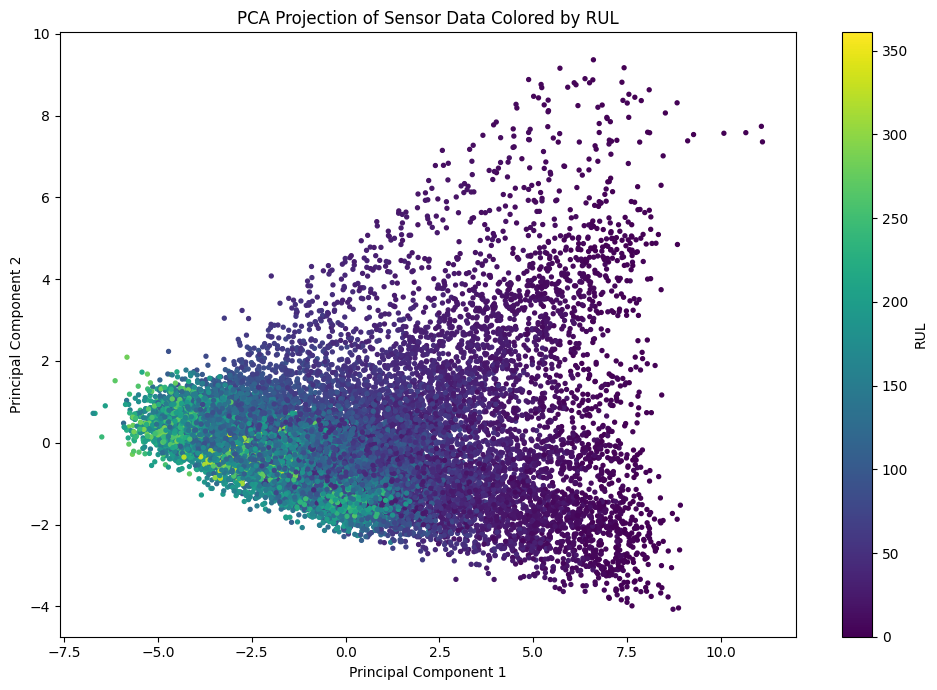

In [23]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_df["PC1"], pca_df["PC2"], c=pca_df["RUL"], s=8)
plt.colorbar(scatter, label="RUL")
plt.title("PCA Projection of Sensor Data Colored by RUL")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()


## 15. Summary of EDA Findings

Write this in your report:

- The NASA C-MAPSS FD001 dataset contains homogeneous turbofan engine degradation histories.
- Each engine is monitored over multiple cycles until failure.
- RUL was calculated from each engine's maximum cycle.
- No major missing value issues were observed.
- Engine lifetimes vary across the fleet, confirming different degradation trajectories.
- Some sensors show stronger relationships with RUL than others.
- Certain sensors have very low variance and may be removed during feature selection.
- Sensor trends and RUL curves show progressive degradation patterns.
- PCA visualization suggests that multivariate sensor data contains useful degradation-related structure.


## 16. Project Methodology Diagram

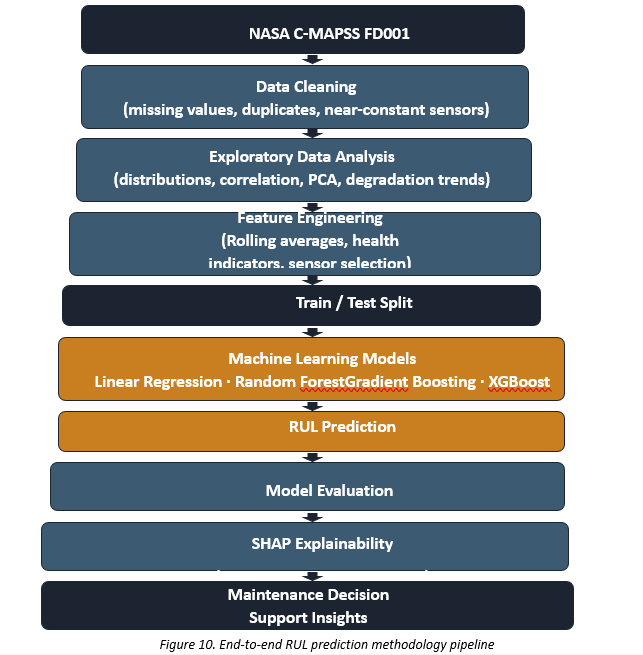

## 17. Next Steps

The next stage of the project will include:

1. Feature selection and scaling.
2. Development of regression models:
   - Linear Regression
   - Random Forest Regressor
   - Gradient Boosting Regressor
   - XGBoost Regressor
3. Model evaluation using:
   - MAE
   - RMSE
   - R²
4. SHAP explainability to identify key degradation indicators.
